Test Accuracy: 0.8778

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        46
           1       0.87      0.89      0.88        44

    accuracy                           0.88        90
   macro avg       0.88      0.88      0.88        90
weighted avg       0.88      0.88      0.88        90


Confusion Matrix:
[[40  6]
 [ 5 39]]

Model coefficients: [1.46275052 0.42799067 1.15498182]
Model intercept: 0.4602139546717992


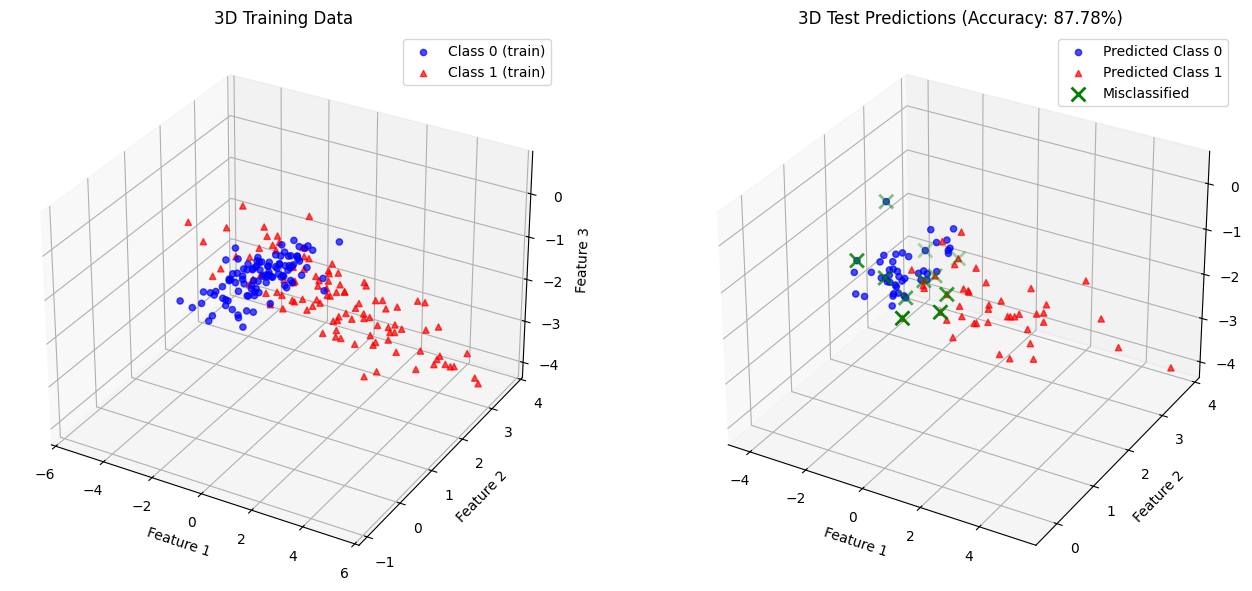


Sample predictions with confidence scores:
Sample 1: true=1, pred=0, prob0=0.607, prob1=0.393
Sample 2: true=1, pred=1, prob0=0.237, prob1=0.763
Sample 3: true=0, pred=0, prob0=0.993, prob1=0.007
Sample 4: true=0, pred=0, prob0=0.959, prob1=0.041
Sample 5: true=1, pred=1, prob0=0.066, prob1=0.934
Sample 6: true=1, pred=1, prob0=0.181, prob1=0.819
Sample 7: true=0, pred=0, prob0=0.759, prob1=0.241
Sample 8: true=0, pred=0, prob0=0.968, prob1=0.032
Sample 9: true=0, pred=0, prob0=0.685, prob1=0.315
Sample 10: true=1, pred=1, prob0=0.066, prob1=0.934


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generate synthetic data for binary classification.
# We use 3 features so the result can be visualized in 3D.
X, y = make_classification(
    n_samples=300,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42,
    class_sep=1.5,
    n_classes=2
)

# Split the dataset into training and testing sets.
# Use stratify=y to preserve class proportions in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Create and train the Logistic Regression model.
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Predict the test set labels and probabilities.
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Evaluate the model.
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Print model coefficients for debugging and interpretation.
print("\nModel coefficients:", model.coef_[0])
print("Model intercept:", model.intercept_[0])

# Visualize training data and test predictions in 3D.
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(
    X_train[y_train == 0, 0], X_train[y_train == 0, 1], X_train[y_train == 0, 2],
    c='blue', marker='o', label='Class 0 (train)', alpha=0.7
)
ax1.scatter(
    X_train[y_train == 1, 0], X_train[y_train == 1, 1], X_train[y_train == 1, 2],
    c='red', marker='^', label='Class 1 (train)', alpha=0.7
)
ax1.set_title('3D Training Data')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(
    X_test[y_pred == 0, 0], X_test[y_pred == 0, 1], X_test[y_pred == 0, 2],
    c='blue', marker='o', label='Predicted Class 0', alpha=0.7
)
ax2.scatter(
    X_test[y_pred == 1, 0], X_test[y_pred == 1, 1], X_test[y_pred == 1, 2],
    c='red', marker='^', label='Predicted Class 1', alpha=0.7
)
misclassified = y_test != y_pred
if np.any(misclassified):
    ax2.scatter(
        X_test[misclassified, 0], X_test[misclassified, 1], X_test[misclassified, 2],
        c='green', marker='x', s=100, label='Misclassified', linewidths=2
    )
ax2.set_title(f'3D Test Predictions (Accuracy: {accuracy:.2%})')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')
ax2.legend()

plt.tight_layout()
plt.show()

# Show sample predictions with confidence scores.
print("\nSample predictions with confidence scores:")
for i in range(min(10, len(X_test))):
    print(
        f"Sample {i+1}: true={y_test[i]}, pred={y_pred[i]}, "
        f"prob0={y_pred_proba[i, 0]:.3f}, prob1={y_pred_proba[i, 1]:.3f}"
    )